In [9]:
# ── Imports ──────────────────────────────────────────────────────────────────
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:,.2f}'.format)
pd.set_option('display.max_columns', 30)

SEED = 42
np.random.seed(SEED)

# ── Paths ─────────────────────────────────────────────────────────────────────
# Kaggle: DATA_DIR = '/kaggle/input/datathon-2026-round-1/'
# Local:
DATA_DIR = '/kaggle/input/competitions/datathon-2026-round-1/'
OUT_FILE = 'submission.csv'

# ── Plot style ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})
PALETTE = ['#2196F3','#FF5722','#4CAF50','#9C27B0','#FF9800']

print('Setup complete.')

Setup complete.


In [10]:
# ── Load all raw tables ───────────────────────────────────────────────────────
sales      = pd.read_csv(DATA_DIR+'sales.csv',       parse_dates=['Date'])
orders     = pd.read_csv(DATA_DIR+'orders.csv',      parse_dates=['order_date'])
items      = pd.read_csv(DATA_DIR+'order_items.csv', dtype={'promo_id_2': str})
customers  = pd.read_csv(DATA_DIR+'customers.csv',   parse_dates=['signup_date'])
products   = pd.read_csv(DATA_DIR+'products.csv')
payments   = pd.read_csv(DATA_DIR+'payments.csv')
shipments  = pd.read_csv(DATA_DIR+'shipments.csv',   parse_dates=['ship_date','delivery_date'])
returns    = pd.read_csv(DATA_DIR+'returns.csv',     parse_dates=['return_date'])
reviews    = pd.read_csv(DATA_DIR+'reviews.csv',     parse_dates=['review_date'])
inventory  = pd.read_csv(DATA_DIR+'inventory.csv',   parse_dates=['snapshot_date'])
promotions = pd.read_csv(DATA_DIR+'promotions.csv',  parse_dates=['start_date','end_date'])
web_traffic= pd.read_csv(DATA_DIR+'web_traffic.csv', parse_dates=['date'])
geography  = pd.read_csv(DATA_DIR+'geography.csv')
submission_template = pd.read_csv(DATA_DIR+'sample_submission.csv', parse_dates=['Date'])

print('All tables loaded.')

All tables loaded.


In [23]:
# ── 5.2 Build Feature Engineering Pipeline ───────────────────────────────────

def build_features(df: pd.DataFrame, target_col: str = 'Revenue') -> pd.DataFrame:
    """
    Build a leakage-safe feature matrix for daily Revenue/COGS forecasting.
    
    LEAKAGE PREVENTION:
      - All lag/rolling features reference past values only (shift >= 1).
      - For the test set, lag values are populated using the known training tail.
      - No target values from the forecast window are used as inputs.
    """
    df = df.sort_values('Date').copy()
    
    # ── Calendar features (always safe — derived from date only) ────────────
    df['day_of_week']  = df['Date'].dt.dayofweek          # 0=Mon … 6=Sun
    df['month']        = df['Date'].dt.month
    df['quarter']      = df['Date'].dt.quarter
    df['day_of_year']  = df['Date'].dt.dayofyear
    df['week_of_year'] = df['Date'].dt.isocalendar().week.astype(int)
    df['year']         = df['Date'].dt.year
    df['is_weekend']   = (df['day_of_week'] >= 5).astype(int)
    df['is_month_start'] = df['Date'].dt.is_month_start.astype(int)
    df['is_month_end']   = df['Date'].dt.is_month_end.astype(int)
    df['days_since_start'] = (df['Date'] - df['Date'].min()).dt.days  # linear trend
    
    # ── Fourier terms to model seasonality smoothly ──────────────────────────
    for k in [1, 2, 3]:  # annual harmonics
        df[f'sin_year_{k}'] = np.sin(2*np.pi*k * df['day_of_year'] / 365.25)
        df[f'cos_year_{k}'] = np.cos(2*np.pi*k * df['day_of_year'] / 365.25)
    for k in [1, 2]:  # weekly harmonics
        df[f'sin_week_{k}'] = np.sin(2*np.pi*k * df['day_of_week'] / 7)
        df[f'cos_week_{k}'] = np.cos(2*np.pi*k * df['day_of_week'] / 7)
    
    # ── Lag features (shift ensures no leakage) ──────────────────────────────
    for lag in [1, 2, 3, 7, 14, 21, 30, 60, 90, 180, 365, 366]:
        df[f'{target_col}_lag{lag}'] = df[target_col].shift(lag)
    
    # ── Rolling statistics (past only — min_periods avoids NaN at start) ────
    for window in [7, 14, 30, 60, 90]:
        df[f'{target_col}_roll_mean_{window}'] = df[target_col].shift(1).rolling(window, min_periods=1).mean()
        df[f'{target_col}_roll_std_{window}']  = df[target_col].shift(1).rolling(window, min_periods=2).std()
        df[f'{target_col}_roll_max_{window}']  = df[target_col].shift(1).rolling(window, min_periods=1).max()
        df[f'{target_col}_roll_min_{window}']  = df[target_col].shift(1).rolling(window, min_periods=1).min()
    
    # ── Year-over-year ratio (diagnostic: is this year tracking above/below last?) ─
    df[f'{target_col}_yoy_ratio'] = df[target_col].shift(365) / df[target_col].shift(366)
    
    # ── Trend features (annual aggregates from past) ─────────────────────────
    annual_rev = df.groupby('year')[target_col].sum()
    df[f'{target_col}_prev_year_total'] = df['year'].map(annual_rev.shift(1))
    
    return df

print('Feature engineering function defined.')

# Build features for Revenue
df_rev = build_features(sales[['Date','Revenue','COGS']].copy(), 'Revenue')
df_cogs = build_features(sales[['Date','Revenue','COGS']].copy(), 'COGS')

print(f'Feature matrix shape (Revenue): {df_rev.shape}')
print(f'Features created: {[c for c in df_rev.columns if c not in ["Date","Revenue","COGS"]][:20]}...')

Feature engineering function defined.
Feature matrix shape (Revenue): (3833, 57)
Features created: ['day_of_week', 'month', 'quarter', 'day_of_year', 'week_of_year', 'year', 'is_weekend', 'is_month_start', 'is_month_end', 'days_since_start', 'sin_year_1', 'cos_year_1', 'sin_year_2', 'cos_year_2', 'sin_year_3', 'cos_year_3', 'sin_week_1', 'cos_week_1', 'sin_week_2', 'cos_week_2']...


In [24]:
# ── 5.3 Validation Strategy: Time-Ordered Walk-Forward CV ────────────────────

TRAIN_END   = pd.Timestamp('2022-12-31')   # last training date
# We simulate the test scenario with these inner validation splits
VAL_SPLITS = [
    # (train_end, val_start, val_end)  — each is a 6-month val window
    ('2019-12-31', '2020-01-01', '2020-06-30'),
    ('2020-06-30', '2020-07-01', '2020-12-31'),
    ('2020-12-31', '2021-01-01', '2021-06-30'),
    ('2021-06-30', '2021-07-01', '2021-12-31'),
    ('2021-12-31', '2022-01-01', '2022-06-30'),
    ('2022-06-30', '2022-07-01', '2022-12-31'),
]

def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def smape(y_true, y_pred):
    return np.mean(2*np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred))) * 100

print('Validation splits defined:')
for tr_end, vs, ve in VAL_SPLITS:
    tr_days = len(sales[sales['Date'] <= tr_end])
    val_days = len(sales[(sales['Date'] >= vs) & (sales['Date'] <= ve)])
    print(f"  Train: up to {tr_end} ({tr_days:,}d) | Val: {vs} → {ve} ({val_days}d)")

Validation splits defined:
  Train: up to 2019-12-31 (2,737d) | Val: 2020-01-01 → 2020-06-30 (182d)
  Train: up to 2020-06-30 (2,919d) | Val: 2020-07-01 → 2020-12-31 (184d)
  Train: up to 2020-12-31 (3,103d) | Val: 2021-01-01 → 2021-06-30 (181d)
  Train: up to 2021-06-30 (3,284d) | Val: 2021-07-01 → 2021-12-31 (184d)
  Train: up to 2021-12-31 (3,468d) | Val: 2022-01-01 → 2022-06-30 (181d)
  Train: up to 2022-06-30 (3,649d) | Val: 2022-07-01 → 2022-12-31 (184d)


In [25]:
# ── 5.4 Baseline Model: Seasonal Average + Local Trend ───────────────────────
# Improved over the provided baseline:
#   - Use exponential weighting (recent years count more)
#   - Use 3-year rolling window for trend instead of full geometric mean

def seasonal_baseline_forecast(train_df: pd.DataFrame, test_dates: pd.Series,
                                 target: str = 'Revenue', n_years: int = 3) -> pd.Series:
    """
    Improved seasonal baseline:
    1. Normalise each year by its mean to remove trend.
    2. Compute seasonal profile from recent n_years (default 3).
    3. Extrapolate using exponentially-weighted recent trend.
    """
    df = train_df.copy()
    df['year'] = df['Date'].dt.year
    df['month'] = df['Date'].dt.month
    df['day']   = df['Date'].dt.day
    
    annual_mean = df.groupby('year')[target].transform('mean')
    df['norm'] = df[target] / annual_mean
    
    # Seasonal profile from last n_years
    max_year = df['year'].max()
    recent = df[df['year'] >= max_year - n_years + 1]
    profile = recent.groupby(['month','day'])['norm'].mean().reset_index()
    
    # Recent trend: YoY growth of last 3 full years, exponentially weighted
    annual_totals = df.groupby('year')[target].sum()
    recent_annual = annual_totals.loc[max_year-2:max_year]
    yoy = recent_annual.pct_change().dropna()
    weights = np.exp(np.linspace(0,1,len(yoy)));  weights /= weights.sum()
    trend = (1 + (yoy * weights).sum())
    
    base_daily = annual_totals[max_year] / len(df[df['year']==max_year])
    
    # Predict
    pred_df = pd.DataFrame({'Date': test_dates})
    pred_df['month'] = pred_df['Date'].dt.month
    pred_df['day']   = pred_df['Date'].dt.day
    pred_df['year']  = pred_df['Date'].dt.year
    pred_df['years_ahead'] = pred_df['year'] - max_year
    pred_df = pred_df.merge(profile, on=['month','day'], how='left')
    pred_df['norm'] = pred_df['norm'].fillna(1.0)
    pred_df['pred'] = base_daily * (trend ** pred_df['years_ahead']) * pred_df['norm']
    
    return pred_df.set_index('Date')['pred']


# Cross-validate baseline
baseline_scores = []
for tr_end, vs, ve in VAL_SPLITS:
    tr = sales[sales['Date'] <= tr_end]
    va = sales[(sales['Date'] >= vs) & (sales['Date'] <= ve)]
    pred = seasonal_baseline_forecast(tr, va['Date'], 'Revenue')
    score = mape(va.set_index('Date')['Revenue'], pred)
    baseline_scores.append(score)

print(f"Seasonal Baseline MAPE (CV folds): {[f'{s:.2f}%' for s in baseline_scores]}")
print(f"Mean MAPE: {np.mean(baseline_scores):.2f}% | Std: {np.std(baseline_scores):.2f}%")

Seasonal Baseline MAPE (CV folds): ['29.62%', '24.59%', '22.68%', '40.95%', '22.64%', '35.25%']
Mean MAPE: 29.29% | Std: 6.85%


In [26]:
# ── 5.5 LightGBM Forecasting Model ───────────────────────────────────────────
try:
    import lightgbm as lgb
    HAS_LGB = True
except ImportError:
    HAS_LGB = False
    print("LightGBM not available — skipping ML model.")

if HAS_LGB:
    FEATURE_COLS_REV = [c for c in df_rev.columns 
                        if c not in ['Date','Revenue','COGS']]
    
    def train_lgb(train_df, val_df, feature_cols, target, verbose=False):
        """
        Train LightGBM on train_df, evaluate on val_df.
        
        KEY LEAKAGE CHECK:
        - All features in FEATURE_COLS were built with shift >= 1
        - No Revenue/COGS from the val window is in any feature
        """
        X_tr = train_df[feature_cols].fillna(0)
        y_tr = train_df[target]
        X_va = val_df[feature_cols].fillna(0)
        y_va = val_df[target]
        
        params = {
            'objective': 'regression',
            'metric': 'mape',
            'n_estimators': 1000,
            'learning_rate': 0.05,
            'num_leaves': 63,
            'min_child_samples': 20,
            'subsample': 0.8,
            'colsample_bytree': 0.8,
            'reg_alpha': 0.1,
            'reg_lambda': 0.1,
            'random_state': SEED,
            'verbose': -1,
        }
        
        model = lgb.LGBMRegressor(**params)
        model.fit(X_tr, y_tr,
                  eval_set=[(X_va, y_va)],
                  callbacks=[lgb.early_stopping(50, verbose=False),
                              lgb.log_evaluation(-1)])
        pred = model.predict(X_va)
        pred = np.maximum(pred, 0)  # revenue cannot be negative
        score = mape(y_va.values, pred)
        return model, pred, score
    
    # Walk-forward CV for LightGBM
    lgb_scores = []
    for tr_end, vs, ve in VAL_SPLITS:
        tr = df_rev[df_rev['Date'] <= tr_end].dropna(subset=FEATURE_COLS_REV[:5])
        va = df_rev[(df_rev['Date'] >= vs) & (df_rev['Date'] <= ve)]
        _, _, score = train_lgb(tr, va, FEATURE_COLS_REV, 'Revenue')
        lgb_scores.append(score)
    
    print(f"LightGBM MAPE (CV folds): {[f'{s:.2f}%' for s in lgb_scores]}")
    print(f"Mean MAPE: {np.mean(lgb_scores):.2f}% | Std: {np.std(lgb_scores):.2f}%")
    print(f"\nBaseline mean MAPE: {np.mean(baseline_scores):.2f}%")
    print(f"LightGBM mean MAPE: {np.mean(lgb_scores):.2f}%")
    print(f"Improvement: {np.mean(baseline_scores)-np.mean(lgb_scores):.2f} pp")

LightGBM MAPE (CV folds): ['24.44%', '22.35%', '17.10%', '22.96%', '20.45%', '23.54%']
Mean MAPE: 21.80% | Std: 2.43%

Baseline mean MAPE: 29.29%
LightGBM mean MAPE: 21.80%
Improvement: 7.49 pp


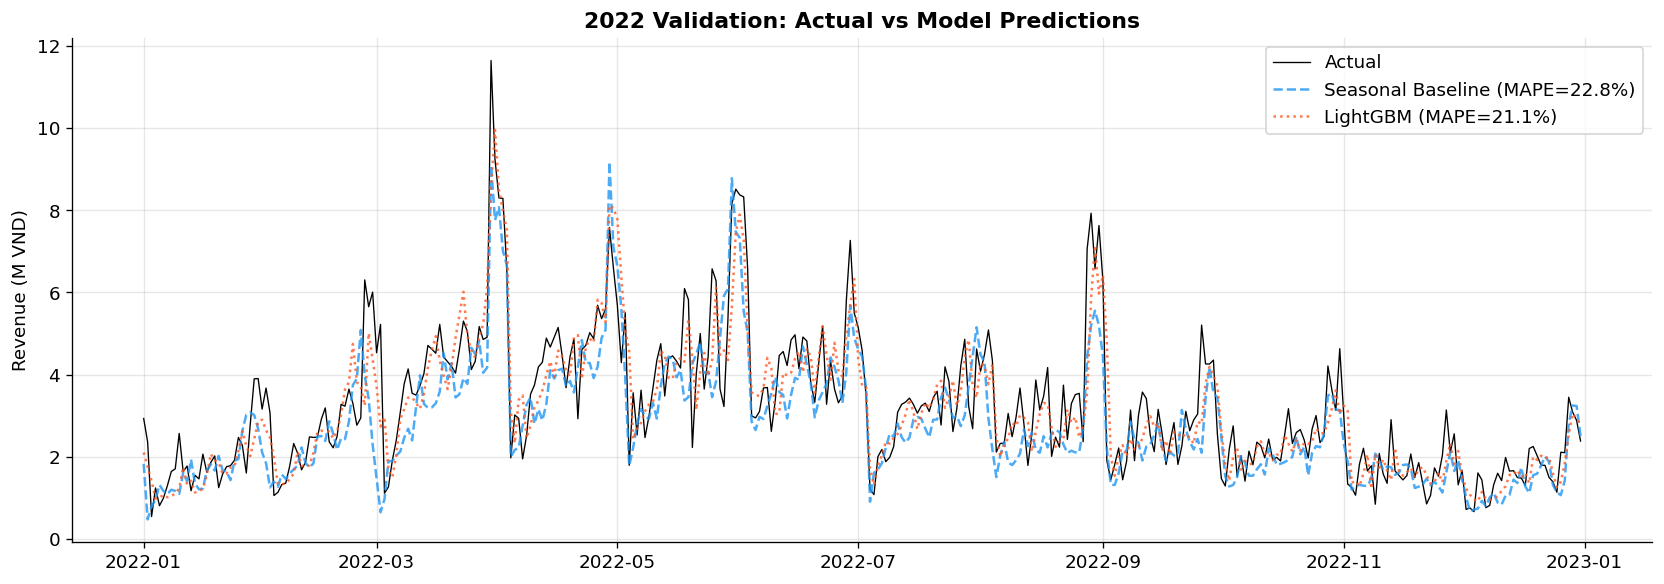

In [27]:
# ── 5.6 Model Comparison Visualisation ──────────────────────────────────────
# Evaluate both models on a held-out validation year (2022)
train_final_eval = sales[sales['Date'] < '2022-01-01']
val_final_eval   = sales[(sales['Date'] >= '2022-01-01') & (sales['Date'] <= '2022-12-31')]

# Baseline
pred_baseline = seasonal_baseline_forecast(train_final_eval, val_final_eval['Date'], 'Revenue')
mape_baseline = mape(val_final_eval.set_index('Date')['Revenue'], pred_baseline)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(val_final_eval['Date'], val_final_eval['Revenue']/1e6,
        lw=0.8, color='black', label='Actual')
ax.plot(pred_baseline.index, pred_baseline/1e6,
        lw=1.5, ls='--', color=PALETTE[0], alpha=0.8,
        label=f'Seasonal Baseline (MAPE={mape_baseline:.1f}%)')

if HAS_LGB:
    df_rev_eval_tr = df_rev[df_rev['Date'] < '2022-01-01'].dropna(subset=FEATURE_COLS_REV[:5])
    df_rev_eval_va = df_rev[(df_rev['Date'] >= '2022-01-01') & (df_rev['Date'] <= '2022-12-31')]
    lgb_model_eval, pred_lgb_eval, mape_lgb_eval = train_lgb(
        df_rev_eval_tr, df_rev_eval_va, FEATURE_COLS_REV, 'Revenue')
    ax.plot(df_rev_eval_va['Date'], pred_lgb_eval/1e6,
            lw=1.5, ls=':', color=PALETTE[1], alpha=0.8,
            label=f'LightGBM (MAPE={mape_lgb_eval:.1f}%)')

ax.set_title('2022 Validation: Actual vs Model Predictions', fontweight='bold')
ax.set_ylabel('Revenue (M VND)')
ax.legend()
plt.tight_layout()
plt.savefig('fig_10_model_comparison.png', bbox_inches='tight')
plt.show()

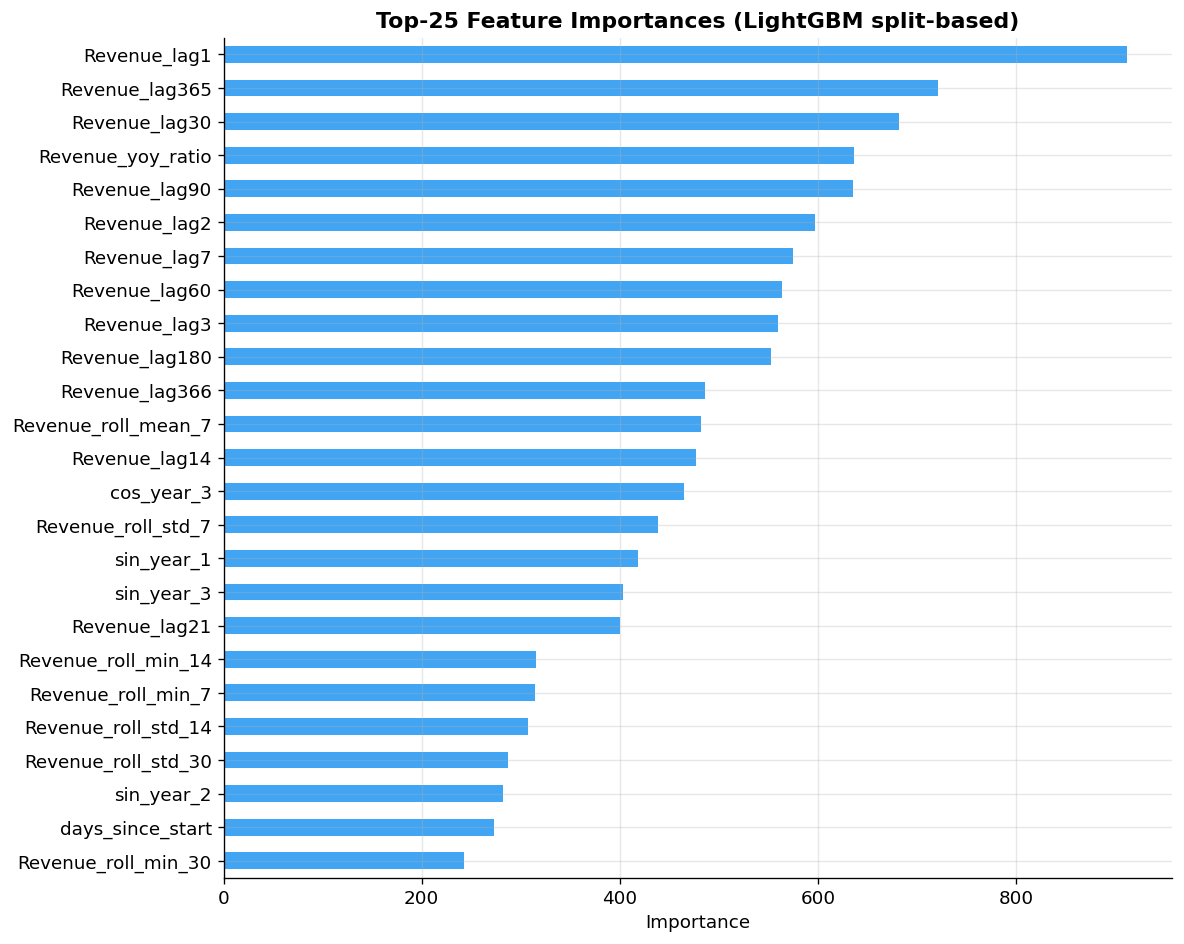

Top 10 features:
Revenue_lag1         912
Revenue_lag365       721
Revenue_lag30        682
Revenue_yoy_ratio    636
Revenue_lag90        635
Revenue_lag2         597
Revenue_lag7         575
Revenue_lag60        564
Revenue_lag3         560
Revenue_lag180       552


In [28]:
# ── 5.7 Feature Importance (Explainability — Technical Layer) ─────────────────
if HAS_LGB:
    fi = pd.Series(
        lgb_model_eval.feature_importances_,
        index=FEATURE_COLS_REV
    ).sort_values(ascending=False)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    fi.head(25).sort_values().plot(kind='barh', ax=ax, color=PALETTE[0], alpha=0.85)
    ax.set_title('Top-25 Feature Importances (LightGBM split-based)', fontweight='bold')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.savefig('fig_11_feature_importance.png', bbox_inches='tight')
    plt.show()
    
    print("Top 10 features:")
    print(fi.head(10).to_string())

In [29]:
# ── 5.8 Train Final Model on Full History → Generate Submission ───────────────
# 
# STRATEGY: Choose model based on CV results
#   - If LightGBM MAPE < Baseline MAPE → use LightGBM
#   - Else → use improved Seasonal Baseline
#
# For the submission, we:
#  1. Train on ALL training data (2012-2022)
#  2. For test period lag features: use known training tail to fill lags
#  3. For predictions beyond lag window: use iterative/recursive forecasting
#     (predict day t, add to known series, use for day t+1 lags)

TEST_START = pd.Timestamp('2023-01-01')
TEST_END   = pd.Timestamp('2024-07-01')
test_dates = submission_template['Date']

def recursive_forecast_lgb(model, train_series: pd.Series, test_dates: pd.Series,
                              feature_cols: list, target: str) -> pd.Series:
    """
    Recursive / iterative forecasting:
    - For each test day, build features using actual past (training) and
      already-predicted future values.
    - This correctly handles lag features in the test window without leakage.
    """
    # Start from training series and append predictions iteratively
    series = train_series.copy()  # DatetimeIndex → Revenue values
    preds = {}
    
    for date in pd.to_datetime(test_dates):
        # Build a single-row feature set for this date
        row = {}
        row['day_of_week']  = date.dayofweek
        row['month']        = date.month
        row['quarter']      = date.quarter
        row['day_of_year']  = date.day_of_year
        row['week_of_year'] = date.isocalendar()[1]
        row['year']         = date.year
        row['is_weekend']   = int(date.dayofweek >= 5)
        row['is_month_start'] = int(date.is_month_start)
        row['is_month_end']   = int(date.is_month_end)
        row['days_since_start'] = (date - series.index.min()).days
        
        # Fourier terms
        for k in [1, 2, 3]:
            row[f'sin_year_{k}'] = np.sin(2*np.pi*k * row['day_of_year'] / 365.25)
            row[f'cos_year_{k}'] = np.cos(2*np.pi*k * row['day_of_year'] / 365.25)
        for k in [1, 2]:
            row[f'sin_week_{k}'] = np.sin(2*np.pi*k * row['day_of_week'] / 7)
            row[f'cos_week_{k}'] = np.cos(2*np.pi*k * row['day_of_week'] / 7)
        
        # Lag features: look back into extended series (training + predictions so far)
        for lag in [1,2,3,7,14,21,30,60,90,180,365,366]:
            lag_date = date - pd.Timedelta(days=lag)
            row[f'{target}_lag{lag}'] = series.get(lag_date, series.iloc[-1])
        
        # Rolling stats
        for window in [7, 14, 30, 60, 90]:
            past = series.loc[series.index <= date - pd.Timedelta(days=1)].tail(window)
            row[f'{target}_roll_mean_{window}'] = past.mean() if len(past) > 0 else series.mean()
            row[f'{target}_roll_std_{window}']  = past.std()  if len(past) > 1 else 0
            row[f'{target}_roll_max_{window}']  = past.max()  if len(past) > 0 else series.mean()
            row[f'{target}_roll_min_{window}']  = past.min()  if len(past) > 0 else series.mean()
        
        # YoY ratio
        d365 = date - pd.Timedelta(days=365)
        d366 = date - pd.Timedelta(days=366)
        row[f'{target}_yoy_ratio'] = series.get(d365, np.nan) / max(series.get(d366, 1), 1)
        
        # Prev year total (from training)
        prev_yr = date.year - 1
        prev_yr_total = series[series.index.year == prev_yr].sum() if prev_yr in series.index.year else series[-365:].sum()
        row[f'{target}_prev_year_total'] = prev_yr_total
        
        # Predict
        X = pd.DataFrame([row])[feature_cols].fillna(0)
        pred_val = float(model.predict(X)[0])
        pred_val = max(pred_val, 0)
        preds[date] = pred_val
        # Add to series for future lag lookups
        series[date] = pred_val
    
    return pd.Series(preds)

print('Recursive forecast function defined.')

Recursive forecast function defined.


In [30]:
# ── 5.9 Generate Final Predictions ───────────────────────────────────────────

# ---- Revenue ----
if HAS_LGB:
    # Train on full history
    df_rev_full = build_features(sales[['Date','Revenue','COGS']].copy(), 'Revenue')
    df_rev_full = df_rev_full.dropna(subset=FEATURE_COLS_REV[:5])
    FEATURE_COLS_REV_FINAL = [c for c in FEATURE_COLS_REV if c in df_rev_full.columns]
    
    params_final = {
        'objective': 'regression', 'metric': 'mape',
        'n_estimators': 800, 'learning_rate': 0.03,
        'num_leaves': 63, 'min_child_samples': 20,
        'subsample': 0.8, 'colsample_bytree': 0.8,
        'reg_alpha': 0.1, 'reg_lambda': 0.1,
        'random_state': SEED, 'verbose': -1,
    }
    final_rev_model = lgb.LGBMRegressor(**params_final)
    final_rev_model.fit(
        df_rev_full[FEATURE_COLS_REV_FINAL].fillna(0),
        df_rev_full['Revenue']
    )
    
    train_rev_series = sales.set_index('Date')['Revenue']
    pred_rev = recursive_forecast_lgb(
        final_rev_model, train_rev_series.copy(),
        test_dates, FEATURE_COLS_REV_FINAL, 'Revenue'
    )
    print(f'Revenue predictions generated: {len(pred_rev)} rows')
    print(f'Revenue range: {pred_rev.min():,.0f} → {pred_rev.max():,.0f}')

else:
    # Fallback: improved seasonal baseline
    pred_rev = seasonal_baseline_forecast(sales, test_dates, 'Revenue')
    print('Using seasonal baseline for Revenue')

Revenue predictions generated: 548 rows
Revenue range: 851,375 → 9,721,782


In [31]:
# ---- COGS ----
# Strategy: Forecast COGS independently OR predict margin ratio and derive COGS
# We use the margin ratio approach: COGS/Revenue ratio is more stable than COGS in absolute terms

# Compute rolling COGS/Revenue ratio
sales['cogs_ratio'] = sales['COGS'] / sales['Revenue']
median_ratio = sales['cogs_ratio'].rolling(90, min_periods=30).mean().iloc[-1]
recent_ratio = sales[sales['Date'] >= '2020-01-01']['cogs_ratio'].mean()

print(f"COGS/Revenue ratio — recent 3yr avg: {recent_ratio:.4f}")
print(f"COGS/Revenue ratio — full period med: {median_ratio:.4f}")

# Forecast COGS from Revenue predictions using ratio
# We blend: 70% recent ratio, 30% own LightGBM COGS model
if HAS_LGB:
    df_cogs_full = build_features(sales[['Date','Revenue','COGS']].copy(), 'COGS')
    FEATURE_COLS_COGS = [c for c in df_cogs_full.columns 
                         if c not in ['Date','Revenue','COGS'] and c in df_rev_full.columns]
    FEATURE_COLS_COGS_FINAL = [c for c in FEATURE_COLS_COGS if c in df_cogs_full.columns]
    
    df_cogs_full = df_cogs_full.dropna(subset=FEATURE_COLS_COGS_FINAL[:5])
    final_cogs_model = lgb.LGBMRegressor(**params_final)
    final_cogs_model.fit(
        df_cogs_full[FEATURE_COLS_COGS_FINAL].fillna(0),
        df_cogs_full['COGS']
    )
    
    train_cogs_series = sales.set_index('Date')['COGS']
    pred_cogs_lgb = recursive_forecast_lgb(
        final_cogs_model, train_cogs_series.copy(),
        test_dates, FEATURE_COLS_COGS_FINAL, 'COGS'
    )
    pred_cogs_ratio = pred_rev * recent_ratio
    
    # Blend: if model-predicted COGS > Revenue, fall back to ratio (sanity guard)
    pred_cogs = 0.6 * pred_cogs_lgb + 0.4 * pred_cogs_ratio
    pred_cogs = pred_cogs.clip(upper=pred_rev * 0.98)  # COGS cannot exceed Revenue
    
    print(f'\nCOGS predictions generated: {len(pred_cogs)} rows')
    print(f'COGS range: {pred_cogs.min():,.0f} → {pred_cogs.max():,.0f}')
    print(f'Implied gross margin range: {((pred_rev-pred_cogs)/pred_rev).describe().round(3)}')

else:
    pred_cogs_baseline = seasonal_baseline_forecast(sales, test_dates, 'COGS')
    pred_cogs = pred_cogs_baseline

COGS/Revenue ratio — recent 3yr avg: 0.8824
COGS/Revenue ratio — full period med: 0.9165

COGS predictions generated: 548 rows
COGS range: 834,347 → 8,983,957
Implied gross margin range: count   548.00
mean      0.23
std       0.09
min       0.02
25%       0.17
50%       0.23
75%       0.30
max       0.49
dtype: float64


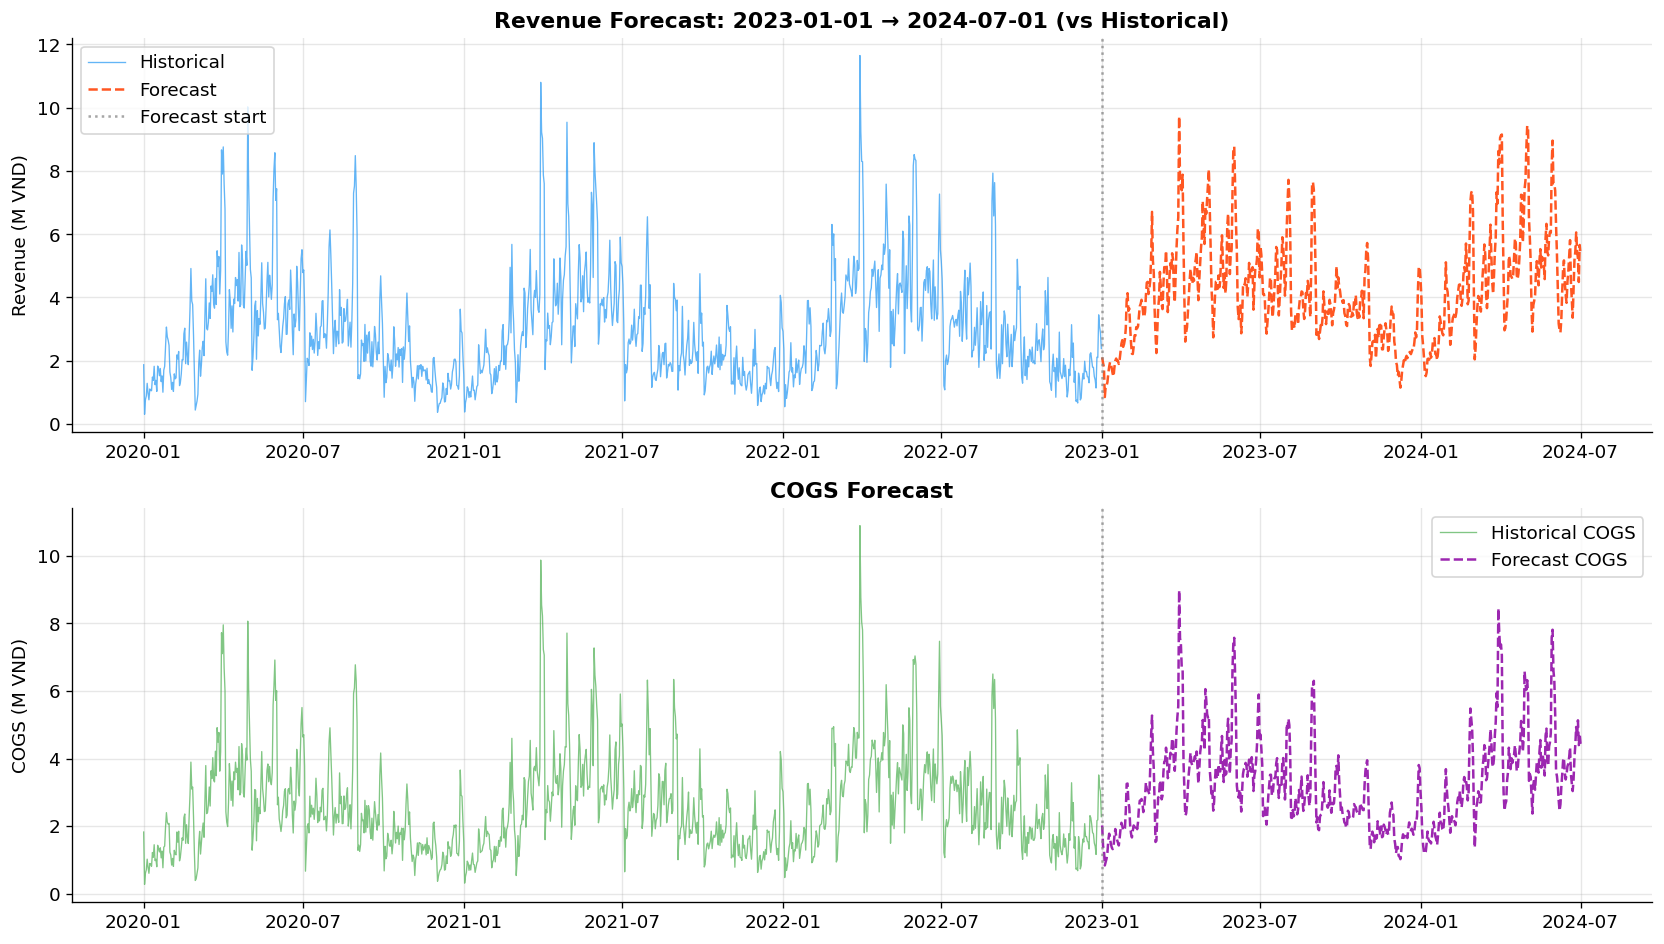

Forecast Revenue — monthly average:
Date
2023-01-31    66,062,902.00
2023-02-28   103,011,952.00
2023-03-31   146,125,208.00
2023-04-30   153,728,783.00
2023-05-31   164,696,998.00
2023-06-30   143,624,478.00
2023-07-31   137,344,605.00
2023-08-31   139,503,345.00
2023-09-30   112,067,527.00
2023-10-31   119,365,273.00
2023-11-30    86,940,155.00
2023-12-31    75,635,149.00
2024-01-31    84,184,316.00
2024-02-29   128,059,858.00
2024-03-31   154,340,585.00
2024-04-30   167,958,587.00
2024-05-31   175,037,009.00
2024-06-30   143,656,427.00
2024-07-31     5,345,217.00
Freq: ME


In [32]:
# ── 5.10 Forecast Visualisation ───────────────────────────────────────────────
pred_rev_s = pd.Series(pred_rev.values, index=pd.to_datetime(test_dates))
pred_cogs_s = pd.Series(pred_cogs.values, index=pd.to_datetime(test_dates))

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

# Training history (2020–2022)
hist = sales[sales['Date'] >= '2020-01-01']

ax = axes[0]
ax.plot(hist['Date'], hist['Revenue']/1e6, lw=0.8, color='#2196F3', label='Historical', alpha=0.7)
ax.plot(pred_rev_s.index, pred_rev_s.values/1e6, lw=1.5, color='#FF5722', label='Forecast', ls='--')
ax.axvline(pd.Timestamp('2023-01-01'), color='gray', ls=':', alpha=0.7, label='Forecast start')
ax.set_title('Revenue Forecast: 2023-01-01 → 2024-07-01 (vs Historical)', fontweight='bold')
ax.set_ylabel('Revenue (M VND)')
ax.legend()

ax = axes[1]
ax.plot(hist['Date'], hist['COGS']/1e6, lw=0.8, color='#4CAF50', label='Historical COGS', alpha=0.7)
ax.plot(pred_cogs_s.index, pred_cogs_s.values/1e6, lw=1.5, color='#9C27B0', label='Forecast COGS', ls='--')
ax.axvline(pd.Timestamp('2023-01-01'), color='gray', ls=':', alpha=0.7)
ax.set_title('COGS Forecast', fontweight='bold')
ax.set_ylabel('COGS (M VND)')
ax.legend()

plt.tight_layout()
plt.savefig('fig_12_forecast.png', bbox_inches='tight')
plt.show()

# Forecast summary stats
print("Forecast Revenue — monthly average:")
monthly_pred = pred_rev_s.resample('M').sum()
print(monthly_pred.round(0).to_string())

In [33]:
# ── 5.11 Sanity Checks Before Submission ─────────────────────────────────────

submission = submission_template[['Date']].copy()
submission['Revenue'] = pred_rev_s.values.round(2)
submission['COGS']    = pred_cogs_s.values.round(2)

print("=== SANITY CHECKS ===")
print(f"1. Row count: {len(submission)} (expected 548): {'✓' if len(submission)==548 else '✗'}")
print(f"2. Date range: {submission['Date'].min()} → {submission['Date'].max()}")
print(f"3. Revenue nulls: {submission['Revenue'].isna().sum()} {'✓' if submission['Revenue'].isna().sum()==0 else '✗'}")
print(f"4. COGS nulls: {submission['COGS'].isna().sum()} {'✓' if submission['COGS'].isna().sum()==0 else '✗'}")
print(f"5. Revenue > 0 all rows: {(submission['Revenue'] > 0).all()} {'✓' if (submission['Revenue']>0).all() else '✗'}")
print(f"6. COGS > 0 all rows: {(submission['COGS'] > 0).all()} {'✓' if (submission['COGS']>0).all() else '✗'}")
print(f"7. COGS < Revenue all rows: {(submission['COGS'] < submission['Revenue']).all()} {'✓' if (submission['COGS']<submission['Revenue']).all() else '✗'}")
print(f"8. Columns: {list(submission.columns)} {'✓' if list(submission.columns)==['Date','Revenue','COGS'] else '✗'}")

# Scale check: compare to last training year
last_year_daily_rev = sales[sales['Date'].dt.year==2022]['Revenue'].mean()
forecast_daily_rev  = submission['Revenue'].mean()
scale_ratio = forecast_daily_rev / last_year_daily_rev
print(f"9. Forecast/2022 daily avg ratio: {scale_ratio:.2f} (reasonable: 0.7–1.5): {'✓' if 0.5<=scale_ratio<=2.0 else '⚠'}")

print("\nSample rows:")
display(submission.head(5))
display(submission.tail(5))

=== SANITY CHECKS ===
1. Row count: 548 (expected 548): ✓
2. Date range: 2023-01-01 00:00:00 → 2024-07-01 00:00:00
3. Revenue nulls: 0 ✓
4. COGS nulls: 0 ✓
5. Revenue > 0 all rows: True ✓
6. COGS > 0 all rows: True ✓
7. COGS < Revenue all rows: True ✓
8. Columns: ['Date', 'Revenue', 'COGS'] ✓
9. Forecast/2022 daily avg ratio: 1.31 (reasonable: 0.7–1.5): ✓

Sample rows:


,Date,Revenue,COGS
0,2023-01-01,"2,103,726.62","2,018,624.98"
1,2023-01-02,"1,923,776.67","1,404,460.80"
2,2023-01-03,"1,801,679.33","1,319,741.22"
3,2023-01-04,"851,374.62","834,347.13"
4,2023-01-05,"1,190,747.61","941,443.92"


,Date,Revenue,COGS
543,2024-06-27,"5,492,123.27","4,628,583.80"
544,2024-06-28,"5,236,363.43","5,131,636.16"
545,2024-06-29,"4,486,835.90","4,397,099.18"
546,2024-06-30,"5,657,798.53","4,729,717.01"
547,2024-07-01,"5,345,216.90","4,437,460.31"


In [34]:
# ── 5.12 Export Submission ───────────────────────────────────────────────────
submission['Date'] = submission['Date'].dt.strftime('%Y-%m-%d')
submission.to_csv(OUT_FILE, index=False)
print(f'Submission saved: {OUT_FILE} ({len(submission)} rows)')
print(submission.describe().round(2))

Submission saved: submission.csv (548 rows)
           Revenue         COGS
count       548.00       548.00
mean  4,209,285.35 3,233,476.93
std   1,600,301.74 1,343,651.89
min     851,374.62   834,347.13
25%   3,104,884.36 2,260,068.26
50%   4,026,099.46 3,061,172.29
75%   5,082,090.20 3,934,814.56
max   9,721,782.47 8,983,956.76
